# Choosing local summaries with relative subsampling

We compare three sampling distributions at three query points to find summaries of local clustering ($H_0$) and loops ($H_1$). We then color every reference point by the $L_1$ norm of its mean stable rank to see whether these summaries distinguish neighborhoods in the data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import stablebear as sb
from stablebear.plotting import plot, plot_distance_weight_heatmap

We also fix the plot styles shared by all figures: one color, line style, and marker per query, the plotted region, and the colormaps for weights and norms.

In [2]:
query_colors = ["#e66101", "#00875a", "#b51f8c"]
query_linestyles = ["-", "--", ":"]
query_markers = ["X", "s", "^"]
extent = (-4.5, 4.5, -3.0, 3.0)  # xmin, xmax, ymin, ymax

weight_cmap = LinearSegmentedColormap.from_list(
    "distance_weight", ["#155477", "#78acc9", "#f5f7f9"]
)
# Keep the point colors dark enough to read on a white background.
norm_cmap = LinearSegmentedColormap.from_list(
    "norm", plt.get_cmap("inferno")(np.linspace(0, 0.6, 256)),
)

## Selecting reference and query points

We start with a point cloud and three queries representing different local structures.

In [3]:
np.random.seed(5)
group_centers = np.array([[-2.0, 0.0], [0.0, 0.0], [2.0, 0.0]])

# Left: three small clumps.
clumps = np.vstack([
    0.13 * np.random.randn(10, 2) + [-0.8, -0.6],
    0.13 * np.random.randn(10, 2) + [-0.8, 0.6],
    0.13 * np.random.randn(10, 2) + [0.45, 0.0],
]) + group_centers[0]

# Middle: a Gaussian blob.
blob = 0.9 * np.random.randn(120, 2) + group_centers[1]

# Right: normalize random directions, then add noise around radius 1.1.
ring = np.random.randn(120, 2)
ring = 1.1 * ring / np.linalg.norm(ring, axis=1, keepdims=True)
ring += 0.22 * np.random.randn(120, 2) + group_centers[2]

reference = sb.PointCloud(np.vstack([clumps, blob, ring]))
points = np.asarray(reference)
queries = np.array([[-2.0, 0.0], [0.0, 0.0], [3.0, 0.0]])

The figure shows the reference points and the three queries.

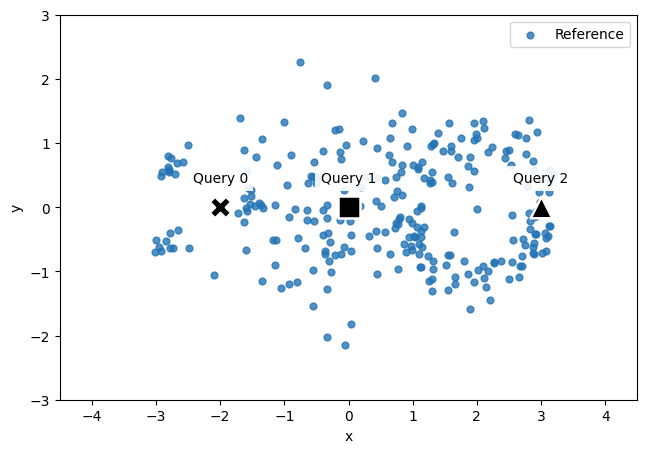

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(*points.T, s=24, color="#2474b5", alpha=0.8, label="Reference")
for q, query in enumerate(queries):
    ax.scatter(*query, marker=query_markers[q], s=240, color="black",
               edgecolors="white", linewidths=1.8, zorder=5)
    ax.annotate(
        f"Query {q}", query, xytext=(0, 18), textcoords="offset points",
        ha="center", color="black", zorder=6,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.9},
    )
ax.set(
    xlim=extent[:2], ylim=extent[2:], xlabel="x", ylabel="y", aspect="equal",
)
ax.legend()
plt.show()

The point cloud has three overlapping groups: sparse clumps on the left, a Gaussian blob in the middle, and a noisy ring on the right. Queries 0, 1, and 2 lie near the clumps, in the blob, and near the ring’s right edge, respectively. These locations help us compare candidate distributions before choosing which to apply across the full point cloud. Queries need not be reference points.

## Comparing sampling distributions

For each query and distribution, we generate 100 bootstrap samples using 30 independent draws **with replacement**. We then remove repeated points with `discard_duplicates=True`, without drawing replacements.

Removing duplicates preserves positive-length persistence bars. Stablebear omits zero-length bars, so this leaves the returned barcodes and their stable-rank $L_1$ norms unchanged. Each sample may contain fewer than 30 distinct points.

In [5]:
distributions = [
    sb.distributions.Gaussian(0, 0.5),
    sb.distributions.Uniform(0, 2.5),
    sb.distributions.Uniform(0.8, 1.5),
]
samples = sb.random.subsample_relative(
    reference, query=queries, n_points=30, n_samples=100,
    replace=True, discard_duplicates=True,
    distribution=distributions, generator=sb.random.Generator(seed=5),
)
assert samples.shape == (3, 3, 100)  # query, distribution, sample

To see where each distribution draws points, we plot its weights around each query together with one sample.

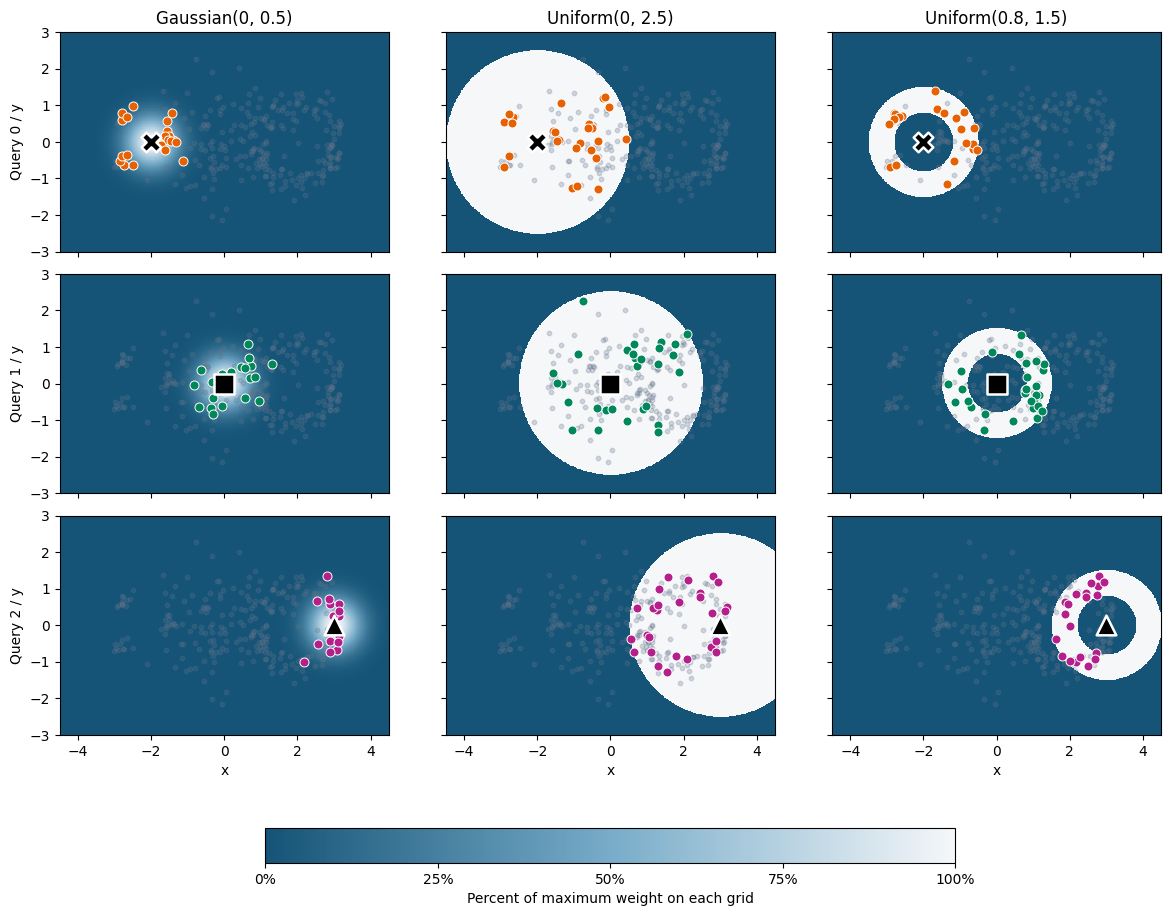

In [6]:
fig, axes = plt.subplots(
    3, 3, figsize=(12, 9), sharex=True, sharey=True, layout="constrained",
)
for d, distribution in enumerate(distributions):
    for q, query in enumerate(queries):
        ax = axes[q, d]
        heatmap = plot_distance_weight_heatmap(
            distribution, query=query, extent=extent, ax=ax, cmap=weight_cmap,
            vmin=0, vmax=100,
        )
        # Rescale each panel to a percentage of its own peak weight.
        weights = heatmap.get_array()
        if weights.max() > 0:
            heatmap.set_data(100 * weights / weights.max())

        selected = np.asarray(samples[q, d, 0])
        ax.scatter(*points.T, s=10, color="#64748b", alpha=0.25)
        ax.scatter(*selected.T, s=42, color=query_colors[q],
                   edgecolors="white", linewidths=0.7)
        ax.scatter(*query, marker=query_markers[q], s=200, color="black",
                   edgecolors="white", linewidths=1.8, zorder=5)
        ax.set(xlim=extent[:2], ylim=extent[2:])

for d, distribution in enumerate(distributions):
    axes[0, d].set_title(str(distribution))
    axes[2, d].set_xlabel("x")
for q in range(len(queries)):
    axes[q, 0].set_ylabel(f"Query {q} / y")
fig.colorbar(
    heatmap, ax=axes, orientation="horizontal",
    label="Percent of maximum weight on each grid",
    ticks=[0, 25, 50, 75, 100],
    format="%g%%", shrink=0.6, pad=0.06,
)
plt.show()

Each panel shows one sample: gray points are the reference, colored points are selected, and black markers identify queries 0 (X), 1 (square), and 2 (triangle). Lighter shading indicates larger weights, shown as a percentage of the maximum on each panel's grid. The shared percentage scale does not imply equal absolute weights.

The Gaussian weight falls off smoothly with distance, so nearby points dominate but farther points can still be drawn. Both Uniforms instead weight every point in their distance range equally and have a sharp boundary: the wider Uniform covers a disk of radius 2.5, and the annular Uniform keeps only points between 0.8 and 1.5 from the query. These choices let us compare different local arrangements.

## Computing stable ranks

We compute $H_0$ and $H_1$ for each sample and convert the resulting barcodes to stable ranks. The sample axis is 2; the last axis indexes homology dimension.

`reduced=True` removes the essential $H_0$ component so the curves have finite norms. $H_1$ is unchanged.

In [7]:
barcodes = sb.persistence.compute_persistent_homology(
    samples, max_dim=1, reduced=True,
)
ranks = sb.persistence.barcode_to_stable_rank(barcodes)
assert ranks.shape == (3, 3, 100, 2)
print("Stable-rank axes: query, distribution, sample, homology:",
      tuple(ranks.shape))

Stable-rank axes: query, distribution, sample, homology: (3, 3, 100, 2)


Averaging over the sample axis gives one mean curve per query, distribution, and homology dimension.

In [8]:
relative_ranks = sb.mean(ranks, dim=2)
assert relative_ranks.shape == (3, 3, 2)
print("Mean axes: query, distribution, homology:",
      tuple(relative_ranks.shape))

Mean axes: query, distribution, homology: (3, 3, 2)


The curve plots below share an x-axis limit and two plotting functions: `plot_query0_curves` shows sample curves and their mean at query 0, and `plot_query_means` compares mean curves across queries.

In [9]:
# Shared x-axis limit for all stable-rank plots.
max_time = max(1.0, np.asarray(sb.max_time(ranks)).max())


def plot_query0_curves(dim, ylabel):
    """Plot 15 sample curves and the mean curve at query 0."""
    fig, axes = plt.subplots(
        1, 3, figsize=(12, 3.5), sharex=True, sharey=True,
        layout="constrained",
    )
    for d, ax in enumerate(axes):
        plot(ranks[0, d, :15, dim], ax=ax, max_time=max_time,
             color="#2474b5", alpha=0.4, linewidth=1.2)
        plot(relative_ranks[0, d, dim], ax=ax, max_time=max_time,
             color=query_colors[0], linewidth=2.8, label="Mean of 100")
        ax.set(title=str(distributions[d]), xlabel="Lifetime threshold",
               xlim=(0, max_time))
    axes[0].set_ylim(bottom=0)
    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    plt.show()


def plot_query_means(dim, ylabel):
    """Plot the mean curve at each query, one panel per distribution."""
    fig, axes = plt.subplots(
        1, 3, figsize=(12, 3.5), sharex=True, sharey=True,
        layout="constrained",
    )
    for d, ax in enumerate(axes):
        for q in range(len(queries)):
            plot(relative_ranks[q, d, dim], ax=ax, max_time=max_time,
                 color=query_colors[q], fmt=query_linestyles[q],
                 linewidth=2.5, label=f"Query {q}")
        ax.set(title=str(distributions[d]), xlabel="Lifetime threshold",
               xlim=(0, max_time))
    axes[0].set_ylim(bottom=0)
    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    plt.show()

## Examining local connectivity with $H_0$

We first examine individual $H_0$ curves and their averages at query 0.

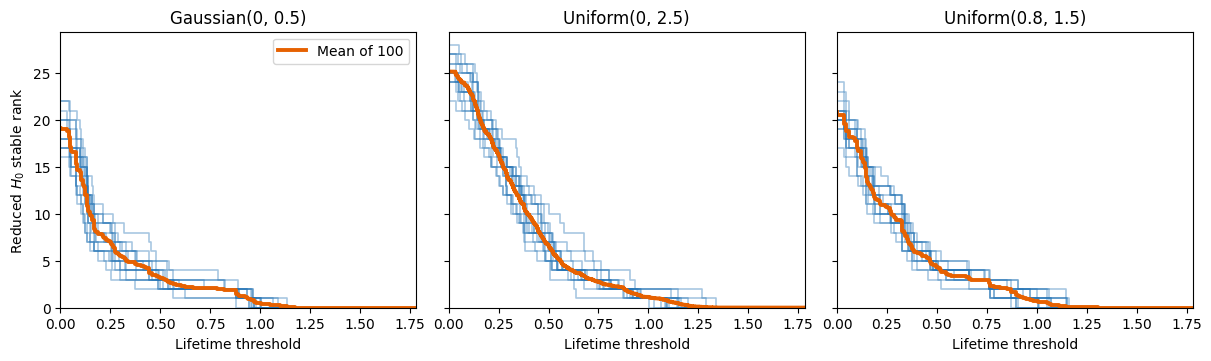

In [10]:
plot_query0_curves(0, "Reduced $H_0$ stable rank")

Blue lines show 15 sample curves for query 0; orange shows the mean of all 100.

For $k$ distinct sampled points, reduced $H_0$ starts at $k - 1$ and drops as components merge. Each finite $H_0$ lifetime is the distance at which a component merges. Repeated draws can change the number of distinct points and thus the starting height.

### Comparing $H_0$ across queries

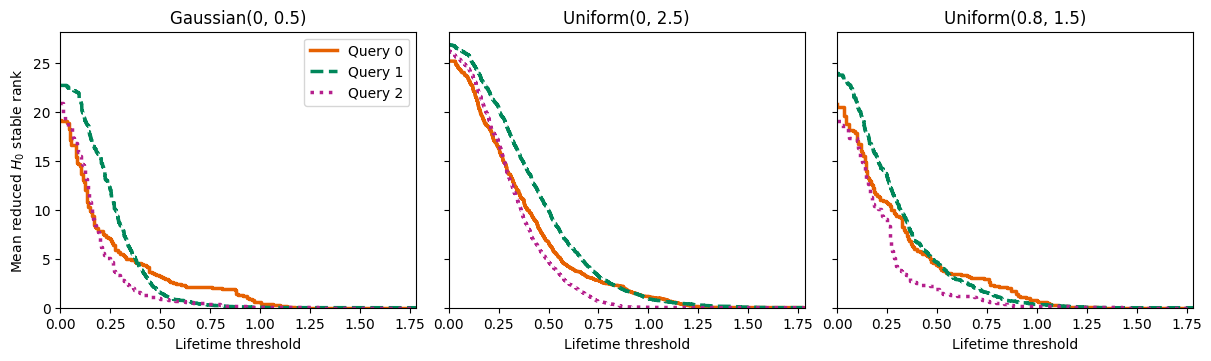

In [11]:
plot_query_means(0, "Mean reduced $H_0$ stable rank")

Queries 0, 1, and 2 use solid, dashed, and dotted lines. With `Gaussian(0, 0.5)`:

- **Left clumps (orange):** an early drop reflects connections within clumps, followed by a shoulder before connections across gaps.
- **Middle blob (green):** components merge over a broader range of distances.
- **Ring edge (purple):** short gaps let most components merge early.

The middle blob stands out: its components keep merging over a longer range of distances. To check whether this difference holds up, we summarize each mean curve with an $L_1$ norm, which gives one value per query.

### Summarizing $H_0$ with a norm

For the mean $H_0$ curve, $\bar{r}_0$,

$$\lVert\bar{r}_0\rVert_1 = \int_0^\infty \bar{r}_0(t)\,dt.$$

This is the average sum of finite $H_0$ lifetimes, or **local connectivity cost**. We compute this norm for every sample curve and for each mean curve.

In [12]:
# Axes (query, distribution, homology) and (query, distribution, sample).
mean_norms = np.asarray(sb.lp_norm(relative_ranks, p=1))
sample_h0_norms = np.asarray(sb.lp_norm(ranks[:, :, :, 0], p=1))
assert mean_norms.shape == (3, 3, 2)
assert sample_h0_norms.shape == (3, 3, 100)

We use box plots to compare the sample norms across queries.

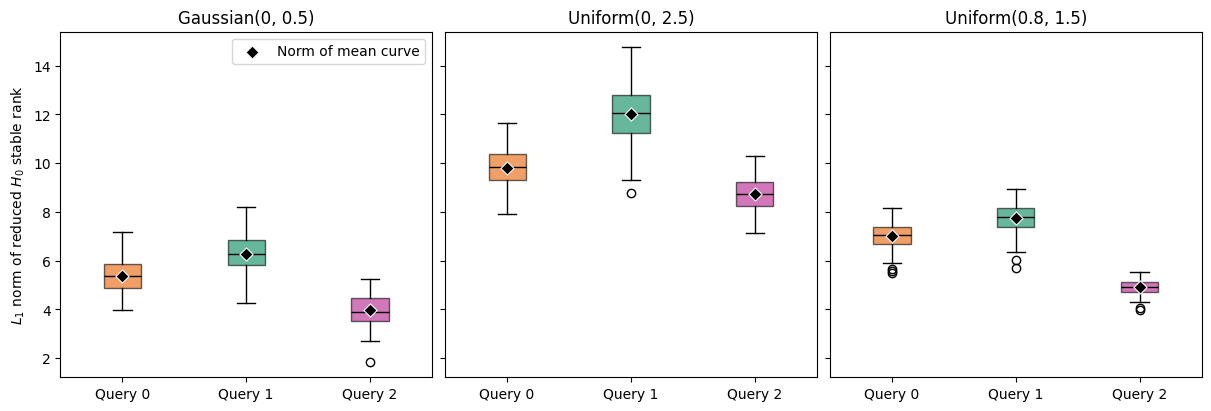

In [13]:
fig, axes = plt.subplots(
    1, 3, figsize=(12, 4), sharey=True, layout="constrained",
)
for d, ax in enumerate(axes):
    boxes = ax.boxplot(
        sample_h0_norms[:, d, :].T, positions=[0, 1, 2],
        patch_artist=True, medianprops={"color": "black"},
    )
    for box, color in zip(boxes["boxes"], query_colors):
        box.set(facecolor=color, alpha=0.6)
    ax.scatter(
        [0, 1, 2], mean_norms[:, d, 0], marker="D", s=45,
        color="black", edgecolors="white", linewidths=0.8,
        zorder=3, label="Norm of mean curve",
    )
    ax.set_title(str(distributions[d]))
    ax.set_xticks([0, 1, 2], ["Query 0", "Query 1", "Query 2"])
axes[0].set_ylabel("$L_1$ norm of reduced $H_0$ stable rank")
axes[0].legend()
plt.show()

The boxes show variation across 100 samples: the middle 50%, median, and whiskers extending to observations within 1.5 interquartile ranges. Outliers appear separately. Black diamonds mark the mean sample norm. Because stable ranks are nonnegative, this equals the norm of the mean curve.

For every distribution, the middle query has the largest norms. The wider Uniform separates it most clearly, but its radius of 2.5 reaches the neighboring groups, so it no longer describes only the local structure. With the Gaussian, the middle box overlaps the left box only slightly, although the sample ranges overlap. We therefore use the Gaussian to check whether the whole central region differs from the rest of the point cloud.

### Coloring points by Gaussian $H_0$

We evaluate the Gaussian $H_0$ summary at every reference point. `norms_at_every_point` repeats the sampling, persistence, and averaging steps above with each reference point as a query, and returns the norm of each mean curve. `plot_norm_map` colors the points by these norms.

In [14]:
def norms_at_every_point(distribution, dim):
    """L1 norm of the mean stable rank with each reference point as query."""
    point_samples = sb.random.subsample_relative(
        reference, query=reference, n_points=30, n_samples=100,
        replace=True, discard_duplicates=True,
        distribution=distribution, generator=sb.random.Generator(seed=6),
    )
    point_barcodes = sb.persistence.compute_persistent_homology(
        point_samples, max_dim=dim, reduced=True,
    )
    point_ranks = sb.persistence.barcode_to_stable_rank(point_barcodes)
    # A single distribution gives axes (query, sample, homology).
    point_means = sb.mean(point_ranks, dim=1)
    norms = np.asarray(sb.lp_norm(point_means[:, dim], p=1))
    assert norms.shape == (len(points),)
    assert np.isfinite(norms).all()
    return norms


def plot_norm_map(norms, title, label):
    """Color every reference point by its norm."""
    fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
    colored = ax.scatter(
        *points.T, c=norms, cmap=norm_cmap, s=35,
        edgecolors="white", linewidths=0.3,
    )
    ax.set(title=title, xlabel="x", ylabel="y",
           xlim=extent[:2], ylim=extent[2:], aspect="equal")
    fig.colorbar(colored, ax=ax, label=label, shrink=0.8)
    plt.show()

We apply them with `Gaussian(0, 0.5)` and $H_0$.

In [15]:
h0_norms = norms_at_every_point(distributions[0], dim=0)

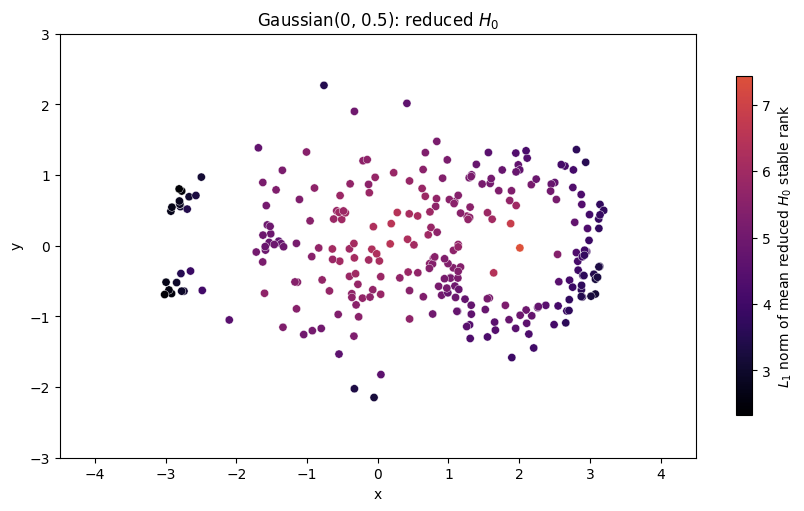

In [16]:
plot_norm_map(
    h0_norms, title=f"{distributions[0]}: reduced $H_0$",
    label="$L_1$ norm of mean reduced $H_0$ stable rank",
)

Each point is colored by the $L_1$ norm of its mean $H_0$ curve under `Gaussian(0, 0.5)`. Larger values mean a greater total distance needed to connect the sampled points. The central region stands out: most points in the middle blob have larger values than points in the clumps or on the ring, and points near the blob's center separate almost completely. Points in the clumps and on the ring have close neighbors, so their sampled points connect at shorter distances.

The number of distinct sampled points also matters: concentrated weights cause more repeated draws, leaving fewer components to connect.

## Examining local loops with $H_1$

We now examine individual $H_1$ curves and their averages at query 0.

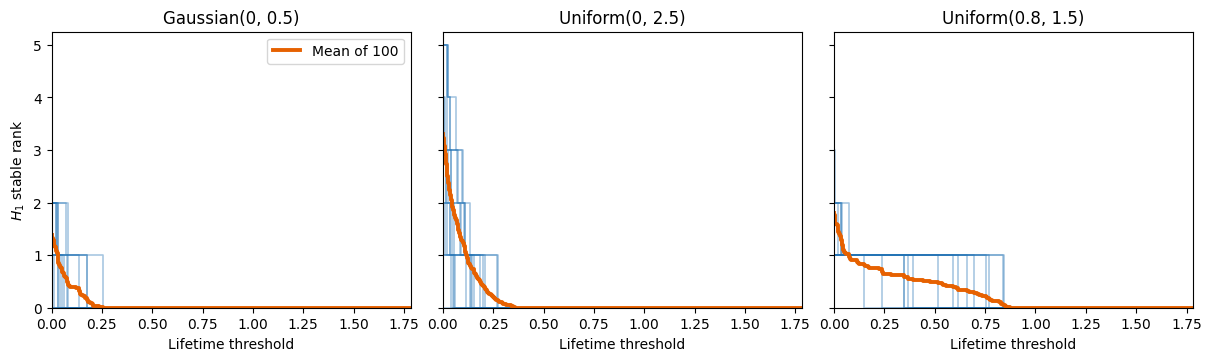

In [17]:
plot_query0_curves(1, "$H_1$ stable rank")

Blue lines show 15 $H_1$ curves for query 0; orange shows the mean of all 100.

$H_1$ stable rank counts loops whose **lifetimes** exceed a threshold, not loops present at that distance scale. Curves extending farther right indicate longer-lived loops.

### Comparing $H_1$ across queries

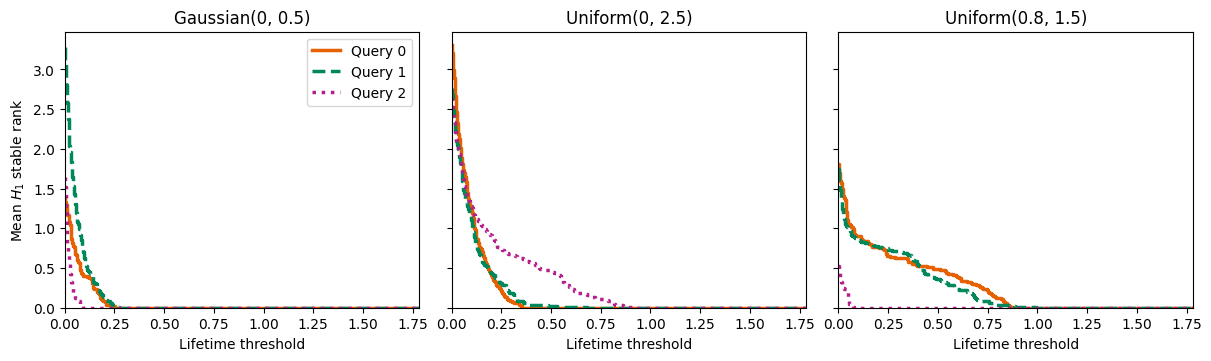

In [18]:
plot_query_means(1, "Mean $H_1$ stable rank")

The line styles identify the same queries as before.

- **Small Gaussian:** all three mean curves decay quickly.
- **Wide Uniform:** the ring-edge query (query 2) has a longer-lived $H_1$ signal.
- **Annulus:** query 2 has little $H_1$, while the other queries produce longer-lived loops.

We choose the annulus for this contrast: near the ring edge it selects fragments of the ring, while elsewhere selected points can surround the excluded center.

### Summarizing $H_1$ with a norm

For the mean $H_1$ curve, $\bar{r}_1$,

$$\lVert\bar{r}_1\rVert_1 = \int_0^\infty \bar{r}_1(t)\,dt.$$

This is the **average total loop persistence**, combining the number of loops and their lifetimes. It describes the sampled neighborhoods: an annular filter can create a hole by excluding central points.

The mean $H_1$ norms quantify these differences.

In [19]:
print("Mean H1 norms for queries 0, 1, 2:")
for d, distribution in enumerate(distributions):
    print(f"  {distribution}: {np.round(mean_norms[:, d, 1], 3)}")

Mean H1 norms for queries 0, 1, 2:
  Gaussian(0, 0.5): [0.107 0.196 0.037]
  Uniform(0, 2.5): [0.305 0.29  0.547]
  Uniform(0.8, 1.5): [0.483 0.431 0.015]


### Coloring points by annular $H_1$

We evaluate the annular $H_1$ summary at every reference point with the same two functions.

In [20]:
h1_norms = norms_at_every_point(distributions[2], dim=1)

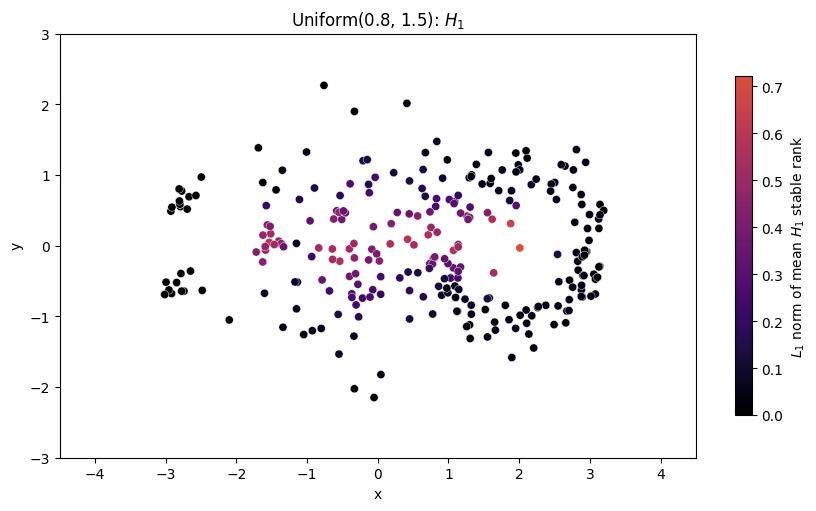

In [21]:
plot_norm_map(
    h1_norms, title=f"{distributions[2]}: $H_1$",
    label="$L_1$ norm of mean $H_1$ stable rank",
)

With `Uniform(0.8, 1.5)`, points near the ring's right edge have low total loop persistence, while many points nearer the middle have higher values. An annulus can select disconnected ring fragments or surround an empty center, depending on its location.

Noise and overlap make the contrast gradual. $H_0$ and $H_1$ use separate color scales because their norms have different ranges.